# Candidate Test 2022 Analysis Part 2

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2). Consider normalizing the data or performing similar scaling transformations as needed.

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:

- An analysis/description of which questions are most crucial concerning their placement on the axes.
- Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.
- A clustering analysis where you attempt various cluster numbers, which would correspond to different parties. Discuss whether there is room for more clusters/parties or if a reduction is needed. Make sure you cover: **K-Means, Hierarchical clustering, and DBSCAN.**
- An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.
- Feel free to explore further and remember that preprocessing, methodology, and evaluation metrics are not mentioned explicitly, but are implicitly assumed.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



___

### Preamble

In [2]:
# Relevant imports for the project
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

### Preprocessing

In [3]:
party_mapping = {
    "Socialdemokratiet": "A",
    "Radikale Venstre": "B",
    "Det Konservative Folkeparti": "C",
    "Nye Borgerlige": "D",
    "Socialistisk Folkeparti": "F",
    "Liberal Alliance": "I",
    "Kristendemokraterne": "K",
    "Moderaterne": "M",
    "Dansk Folkeparti": "O",
    "Danmarksdemokraterne": "Æ",
    "Venstre": "V",
    "Enhedslisten": "Ø",
    "Alternativet": "Å",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "Q",
    "Løsgænger": "L"
}

party_colors = {
    "Socialdemokratiet": "#B22222",
    "Radikale Venstre": "#6A5ACD",
    "Det Konservative Folkeparti": "#9ACD32",
    "Nye Borgerlige": "#2F4F4F",
    "Socialistisk Folkeparti": "#FF1493",
    "Liberal Alliance": "#00CED1",
    "Kristendemokraterne": "#D3D3D3",
    "Moderaterne": "#800080",
    "Dansk Folkeparti": "#DAA520",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#008000",
    "Venstre": "#00008B",
    "Danmarksdemokraterne": "#87CEEB",
    "Enhedslisten": "#D2691E",
    "Alternativet": "#228B22",
    "Løsgænger": "#808080"
}

In [4]:
df = alldata = pd.read_excel('alldata.xlsx')
drdata = pd.read_excel('drdata.xlsx')
drq = pd.read_excel('drq.xlsx')
tv2data = pd.read_excel('tv2data.xlsx')
tv2q = pd.read_excel('tv2q.xlsx')
electeddata = pd.read_excel('electeddata.xlsx')

In [5]:
alldata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 867 entries, 0 to 866
Data columns (total 53 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   530        867 non-null    int64 
 1   531        867 non-null    int64 
 2   533        867 non-null    int64 
 3   534        867 non-null    int64 
 4   535        867 non-null    int64 
 5   537        867 non-null    int64 
 6   538        867 non-null    int64 
 7   540        867 non-null    int64 
 8   541        867 non-null    int64 
 9   543        867 non-null    int64 
 10  544        867 non-null    int64 
 11  545        867 non-null    int64 
 12  546        867 non-null    int64 
 13  547        867 non-null    int64 
 14  548        867 non-null    int64 
 15  550        867 non-null    int64 
 16  551        867 non-null    int64 
 17  552        867 non-null    int64 
 18  553        867 non-null    int64 
 19  555        867 non-null    int64 
 20  556        867 non-null    int64

In [6]:
display(drq)


,ID,Title,Question,Info,ArgumentFor,ArgumentAgainst,WordMerger,ID_CandidateQuestionType,Rule,QuestionListData
0,530,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...,NaN,Den kollektive trafik bør være billig og tilgæ...,Det er dyrt for statskassen at opretholde drif...,0,1,FT,NaN
1,531,ARBEJDSMARKED OG ØKONOMI,Der skal indføres en særlig skat på de allerhø...,NaN,Historisk rammer kriser de fattigste hårdest. ...,Det danske samfund er et af de mest lige samfu...,0,1,FT,NaN
2,533,RET OG STRAF,Kriminalitet begået i udsatte boligområder ska...,NaN,Den mest effektive måde at stoppe bandekrimina...,"Det er urimeligt, at den samme forbrydelse ska...",0,1,FT,NaN
3,534,EU OG UDENRIGS,På sigt skal Danmark meldes ud af EU,NaN,"Så længe Danmark er medlem af EU, kan flertall...",Danmark er bedst tjent med at være en del af E...,0,1,FT,NaN
4,535,EU OG UDENRIGS,"Det er fornuftigt, at Danmark i de kommende år...",NaN,Ruslands angreb på Ukraine har ændret alting o...,Vi er medlemmer af Nato og har i forvejen et s...,0,1,FT,NaN
5,537,VELFÆRD,"Det er okay, at den økonomiske ulighed stiger,...",NaN,Økonomisk ulighed afspejler belønningen den en...,Større økonomisk ulighed vil skævvride samfund...,0,1,FT,NaN
6,538,UDDANNELSE,Forældres indkomst skal være et af kriterierne...,NaN,Det er vigtigt at vores gymnasier består af un...,De unge risikerer at miste pladsen på deres næ...,0,1,FT,NaN
7,540,VELFÆRD,Det skal være muligt at tjene penge på at driv...,NaN,Der er brug for en bred vifte af forskellige d...,Skattekroner tiltænkt velfærd skal ikke kunne ...,0,1,FT,NaN
8,541,ARBEJDSMARKED OG ØKONOMI,Der skal indføres skat på fortjenesten ved sal...,NaN,"Det er kun rimeligt, at man betaler skat af st...","Det er mere sikkert for alle, at boligejere be...",0,1,FT,NaN
9,543,VELFÆRD,"Det er en god idé, at dagpengesatsen for nyudd...",NaN,De fleste nyuddannede er yngre mennesker uden ...,Som nyuddannet er man ofte ved at etablere sig...,0,1,FT,NaN


In [7]:
X = questions = alldata.drop(columns=['parti', 'storkreds', 'alder', 'navn'])

### An analysis/description of which questions are most crucial concerning their placement on the axes.

[comment]: <> (httaps://www.geeksforgeeks.org/principal-component-analysis-pca/)

In [8]:
scaler = StandardScaler()
standardized_data = scaler.fit_transform(questions)
standardized_df = pd.DataFrame(standardized_data, columns=questions.columns)

In [9]:
pca = PCA()
pca.fit_transform(standardized_df)

array([[-3.36218540e+00, -1.51693021e+00, -2.40188841e+00, ...,
         2.03078058e-01, -4.51022379e-03,  4.02438848e-01],
       [ 6.09174875e+00,  1.19195160e+00,  8.18218331e-01, ...,
         3.63547473e-01, -1.30521356e-01,  4.14991633e-01],
       [ 4.96018236e+00, -1.09600691e+00,  3.64587283e-01, ...,
        -1.22863609e-01,  4.79962075e-01,  1.64138898e-01],
       ...,
       [ 1.80341626e+00,  3.10438308e+00, -2.95606419e+00, ...,
        -1.43045935e-01, -4.34069177e-02, -1.09352385e-01],
       [ 4.59531877e-01,  1.60482336e+00, -7.63271892e-01, ...,
         2.35978224e-01,  1.34734860e-01, -3.42263113e-02],
       [ 4.13132284e+00,  8.46308529e-01, -1.54605845e+00, ...,
         1.22139088e-02,  3.51923916e-02,  1.00153419e-01]],
      shape=(867, 49))

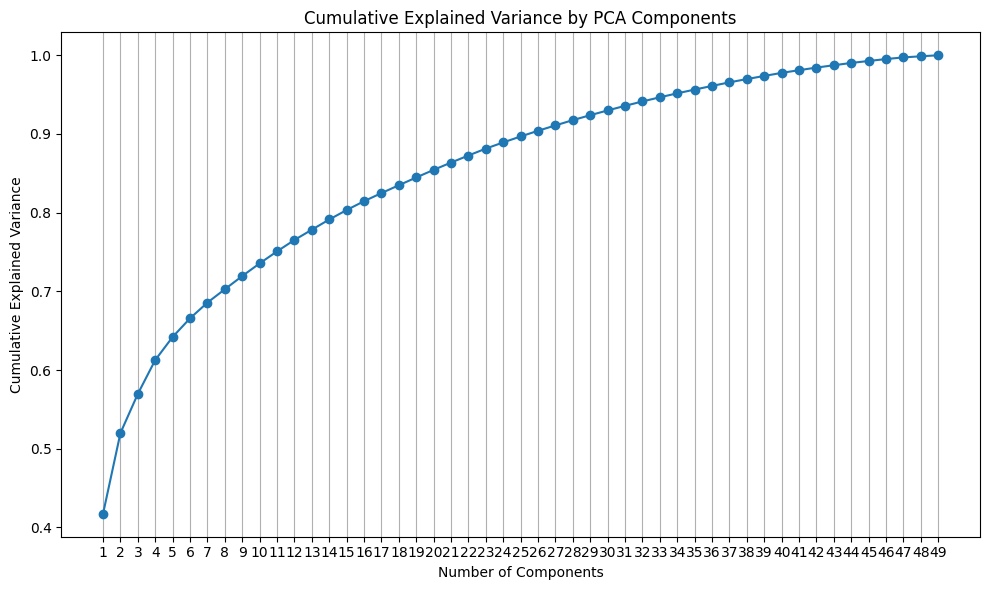

In [10]:
plt.figure(figsize=(10, 6))
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(axis='x')
plt.tight_layout()
plt.show()

Based on the shoulder method we took 5 componencts for our PCA.

In [11]:
n_top_components = 5
pca = PCA(n_components=n_top_components)
pca_result = pca.fit_transform(standardized_df)

In [12]:
loadings = pd.DataFrame(np.abs(pca.components_[:n_top_components]), columns=questions.columns)
feature_importance = loadings.sum(axis=0).sort_values(ascending=False)
top_10_questions = feature_importance.head(10)
top_10_questions

547    0.990820
5b     0.962596
534    0.899869
546    0.843550
7a     0.814717
8a     0.813261
545    0.757066
11b    0.733489
533    0.698689
561    0.695615
dtype: float64

These are the most ideologically distinguishing questions according to the dataset. They are the best indicators of how candidates differ politically. We have reduced the chances of biased by "noise" questions and sped up the clustering by having fewer features.

### Average positions of parties concerning each question and the most crucial ones.

#### All questions with parties average answers

In [13]:
party_question_means = alldata.groupby("parti")[questions.columns].mean()

party_question_means.head(15)

,530,531,533,534,535,537,538,540,541,543,...,8a,8b,9a,9b,10a,10b,11a,11b,12a,12b
parti,,,,,,,,,,,,,,,,,,,,,
Alternativet,1.880597,1.134328,-1.895522,-1.820896,-0.776119,-1.641791,-0.716418,0.283582,1.149254,-1.432836,...,1.268657,1.134328,-1.477612,0.164179,-0.149254,1.029851,0.164179,0.492537,0.492537,-0.671642
Danmarksdemokraterne,-0.837838,-1.378378,1.513514,-0.972973,1.756757,0.189189,-1.864865,1.054054,-1.918919,0.972973,...,1.000000,0.729730,0.567568,-0.702703,0.918919,1.918919,-1.972973,1.891892,0.486486,0.297297
Dansk Folkeparti,-0.571429,-1.081633,1.551020,1.653061,1.551020,0.000000,-1.551020,0.734694,-1.448980,0.510204,...,0.979592,0.489796,0.816327,-0.306122,0.918367,1.448980,-1.693878,1.795918,0.816327,-0.693878
Det Konservative Folkeparti,-0.836735,-1.877551,0.948980,-1.714286,1.816327,1.408163,-1.979592,1.663265,-1.255102,1.397959,...,1.142857,0.275510,0.500000,-0.295918,1.469388,-1.612245,-1.806122,1.806122,0.765306,-0.295918
Enhedslisten,1.959459,1.864865,-1.918919,0.405405,-1.662162,-1.878378,0.418919,-1.797297,1.635135,-1.783784,...,0.824324,0.445946,-1.824324,0.283784,-1.040541,1.905405,0.702703,-1.162162,-0.554054,0.108108
"Frie Grønne, Danmarks Nye Venstrefløjsparti",1.923077,1.923077,-2.000000,-1.692308,-1.769231,-2.000000,-1.769231,-1.461538,1.692308,-1.884615,...,1.230769,0.538462,-1.692308,0.461538,-0.461538,1.615385,-1.115385,1.346154,0.000000,0.269231
Kristendemokraterne,0.880952,-0.666667,-1.285714,-1.595238,1.190476,-0.428571,-1.047619,0.976190,-0.571429,0.071429,...,1.642857,0.928571,-0.690476,0.357143,0.595238,-1.333333,-0.976190,1.023810,1.023810,-0.309524
Liberal Alliance,-1.142857,-1.971429,-0.857143,-1.271429,1.671429,1.900000,-2.000000,1.971429,-1.342857,1.614286,...,0.585714,-0.214286,1.385714,-0.771429,1.671429,-1.928571,-1.957143,1.871429,1.571429,-1.614286
Løsgænger,0.000000,-0.666667,-0.333333,1.000000,0.666667,0.666667,-1.666667,1.333333,2.000000,0.333333,...,1.000000,-1.000000,0.000000,0.000000,0.333333,0.666667,-0.666667,0.000000,1.666667,-2.000000


#### PCA selected crucial questions

The questions selected and visualized below are:
- **547** | Der bør dannes en regering hen over midten.
- **5b** | Der bør tilføres ekstra ressourcer til ældreplejen, selvom dette vil medføre, at andre velfærdsområder får færre ressourcer.
- **534** | På sigt skal Danmark meldes ud af EU.
- **546** | Danmark skal undersøge muligheden for at udvikle A-kraft som energikilde herhjemme.
- **7a** | Indførelse af atomkraft i Danmark vil være et godt bidrag til den grønne omstilling.
- **8a** | Der skal tilføres markant flere ressourcer til psykisk sårbare unge, selvom dette vil medføre, at andre velfærdsområder får færre ressourcer.
- **545** | Pensionsalderen skal fortsætte med at stige i takt med, at levealderen stiger.
- **11b** | Det bør undersøges, om Mette Frederiksen kan stilles for en rigsret som konsekvens af hendes håndtering af Mink-sagen.
- **533** | Kriminalitet begået i udsatte boligområder skal straffes særligt hårdt.
- **561** | Det er en god idé med naturnationalparker, hvor der bliver udsat store dyr, som lever vildt.

The left side (-2.0) represents the **strongly disagree** answers whereas the right side (2.0) stands for **strongly agree**.

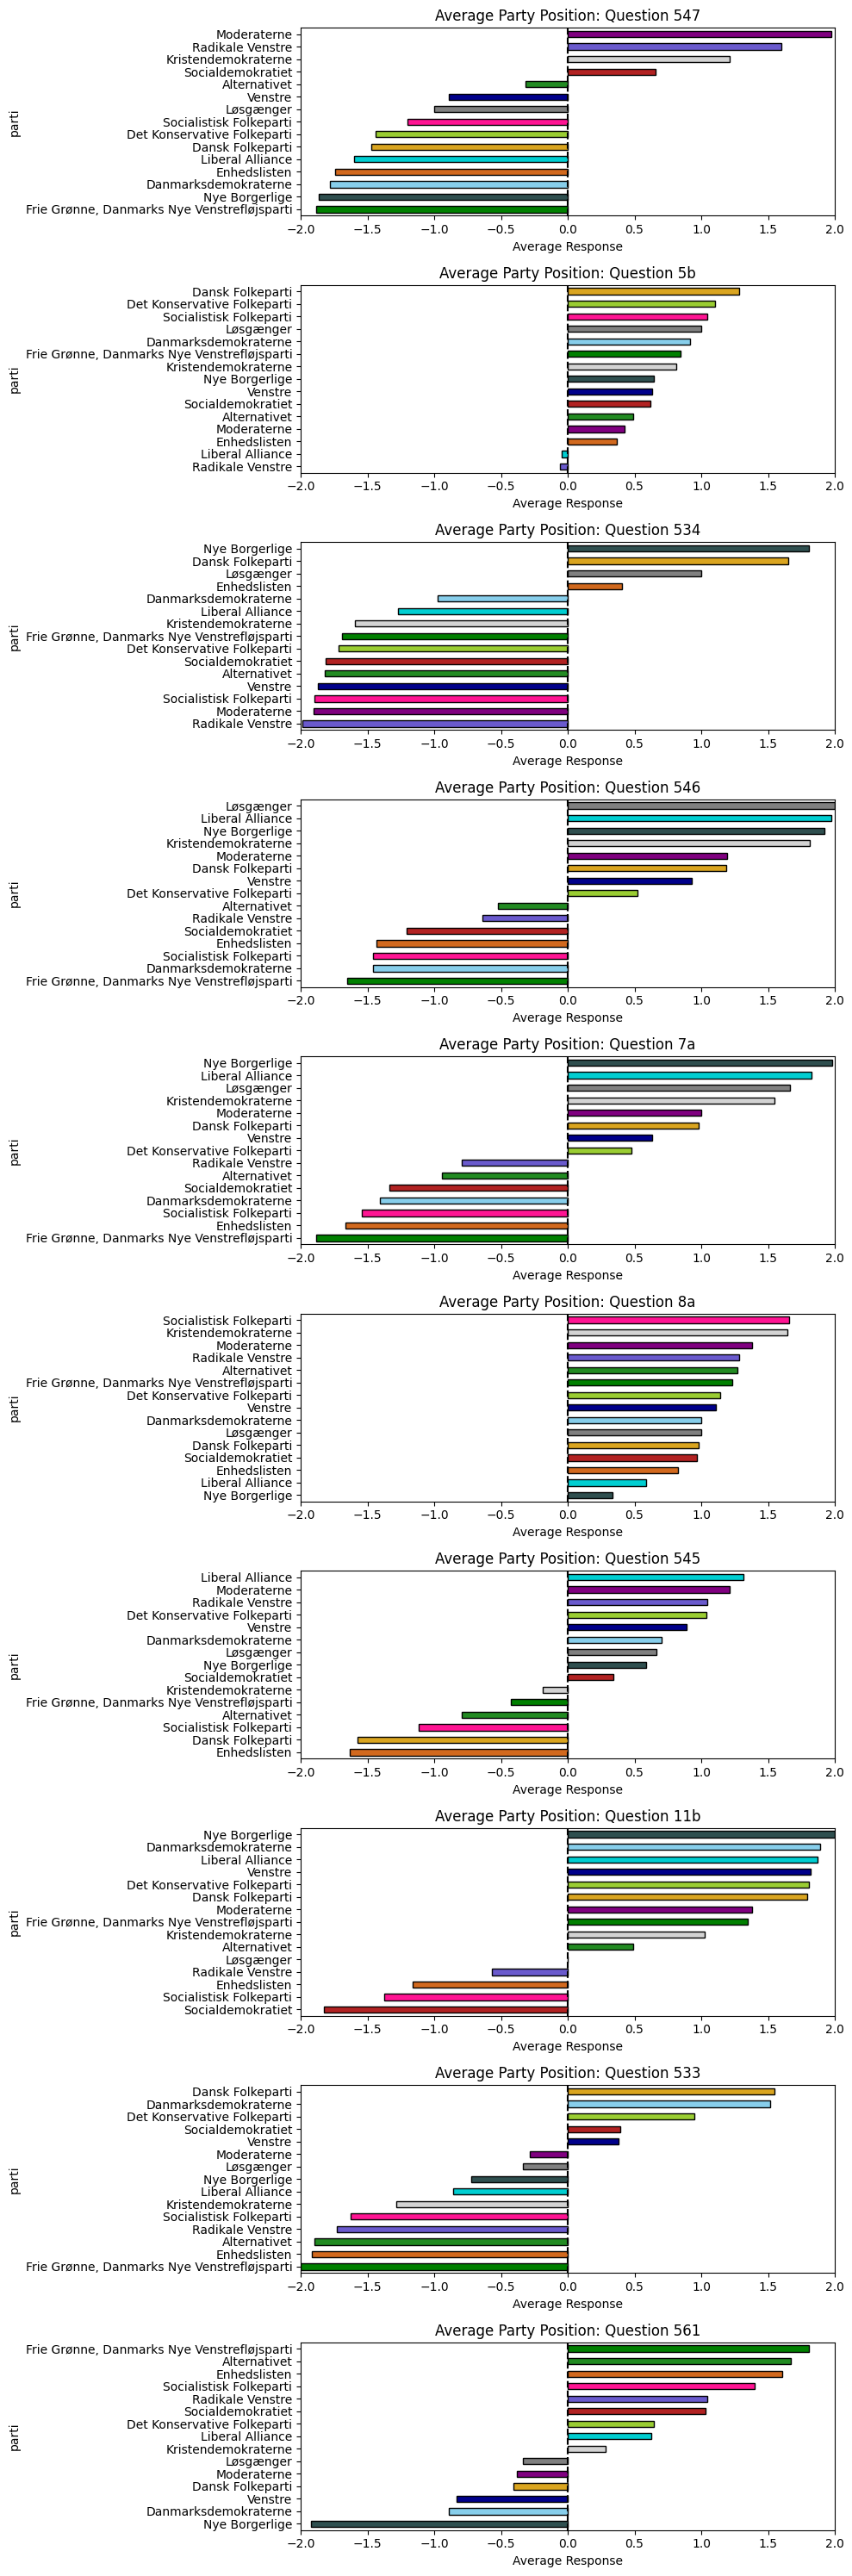

In [14]:
top_10_question_means = party_question_means[top_10_questions.index]

num_questions = len(top_10_question_means.columns)
fig, axes = plt.subplots(nrows=num_questions, figsize=(10, 3 * num_questions))

for idx, question in enumerate(top_10_question_means.columns):
    ax = axes[idx]
    sorted_values = top_10_question_means[question].sort_values()
    sorted_colors = [party_colors.get(party, "#999999") for party in sorted_values.index]
    sorted_values.plot(kind='barh', ax=ax, color=sorted_colors, edgecolor='black')
    ax.set_title(f"Average Party Position: Question {question}")
    ax.set_xlabel("Average Response")
    ax.set_xlim([-2, 2])
    ax.axvline(0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

### Clustering Analysis

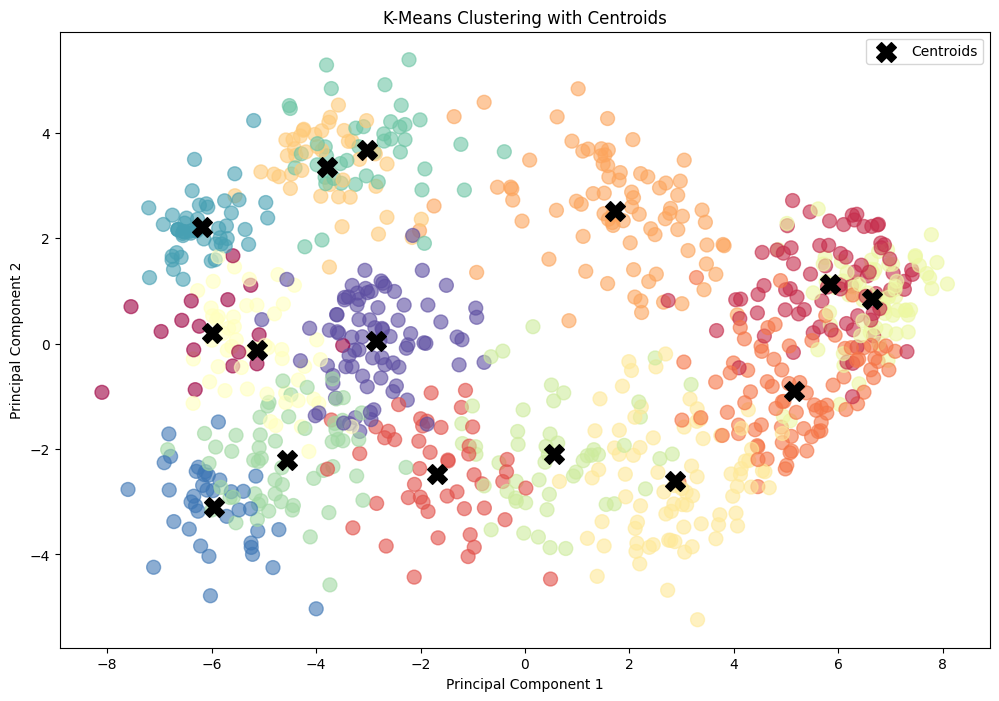

In [15]:
kmeans = KMeans(n_clusters=15)
kmeans_clusters = kmeans.fit_predict(pca_result)

plt.figure(figsize=(12, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans_clusters, cmap='Spectral', s=100, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', marker='X', label='Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering with Centroids')
plt.legend()
plt.show()

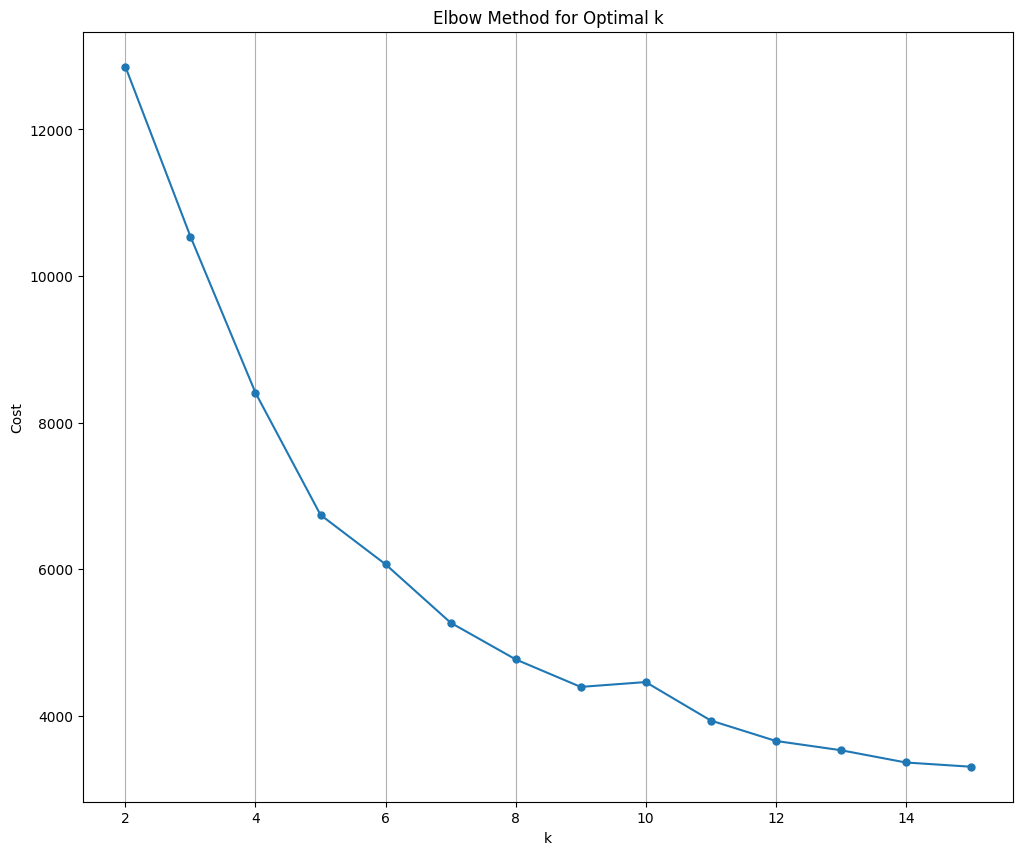

In [16]:
fig, ax = plt.subplots(figsize=(12,10))
costs = []
ks = range(2, 16)
for k in ks:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_result)
    costs.append(kmeans.inertia_)

ax.plot(ks, costs, '.-', markersize=10)
ax.set_xlabel('k')
ax.set_ylabel('Cost')
ax.grid(axis='x')
ax.set_title('Elbow Method for Optimal k')
plt.show()

Using the elbow method we can indentify that the optimal number of clusters is 5.

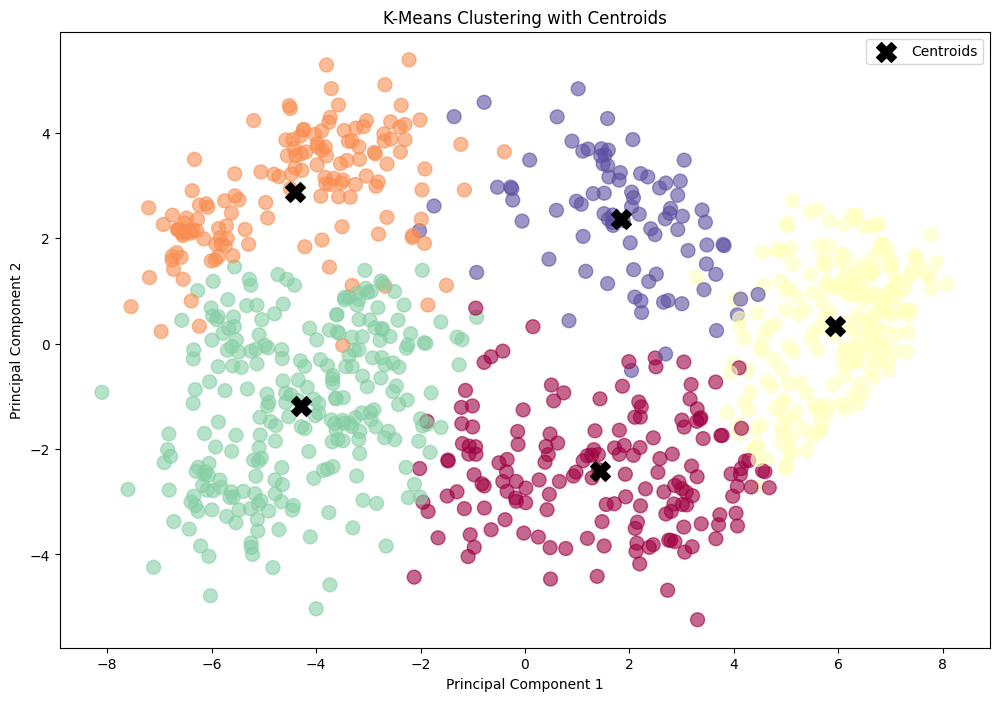

In [17]:
kmeans = KMeans(n_clusters=5)
kmeans_clusters = kmeans.fit_predict(pca_result)

plt.figure(figsize=(12, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans_clusters, cmap='Spectral', s=100, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', marker='X', label='Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering with Centroids')
plt.legend()
plt.show()

#### Hierarchical (Agglomerative) Clustering

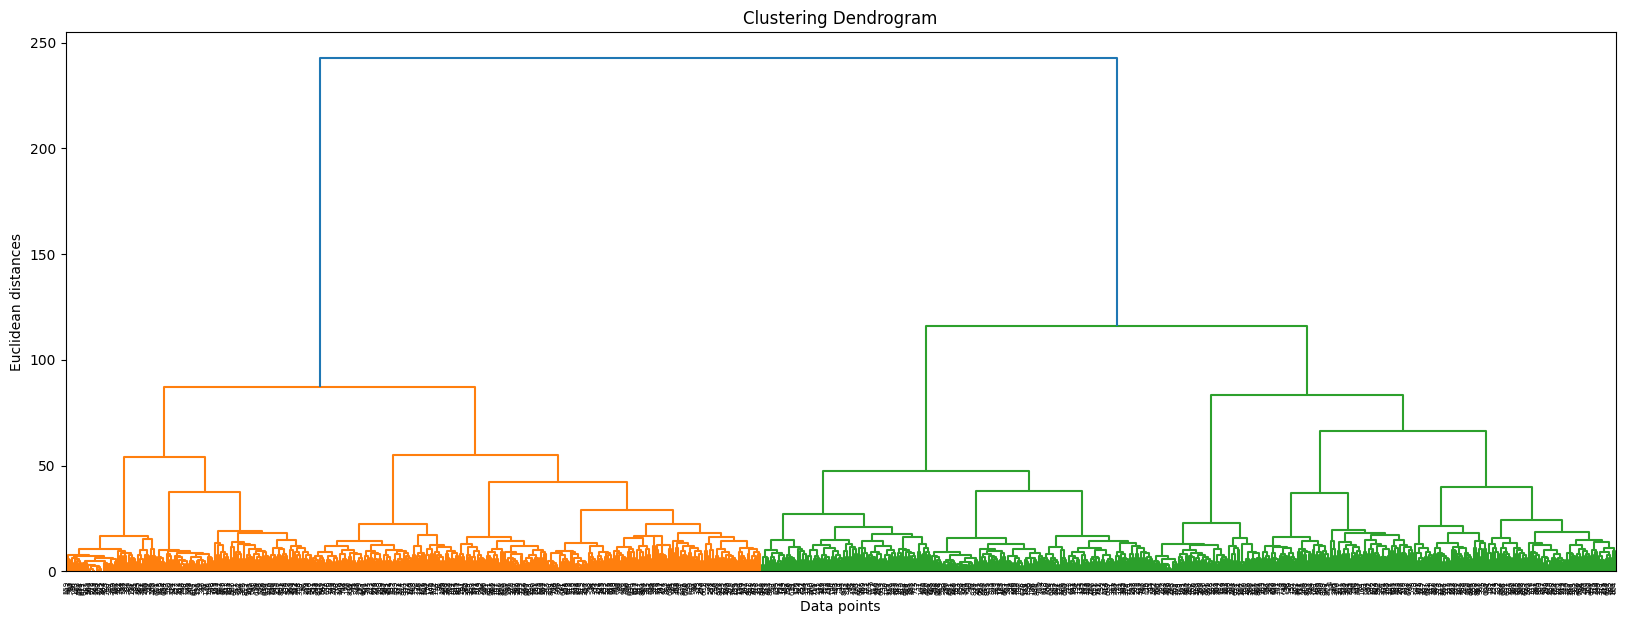

In [18]:
linked = linkage(X, 'ward')

plt.figure(figsize=(20, 7))
dendrogram(linked)
plt.title('Clustering Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidean distances')
plt.show()

Looking at the dendogram we can identify the _longest_ vertical segment without any merging and count how many vertical lines there are in that segment, and get 5.

In [19]:
def plot_agg_clustering(k, method):
    fig, ax = plt.subplots(figsize=(12, 8))
    agg = AgglomerativeClustering(n_clusters=k, linkage=method)
    labels = agg.fit_predict(pca_result)
    ax.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='viridis', s=50, alpha=0.5)
    
    plt.show()

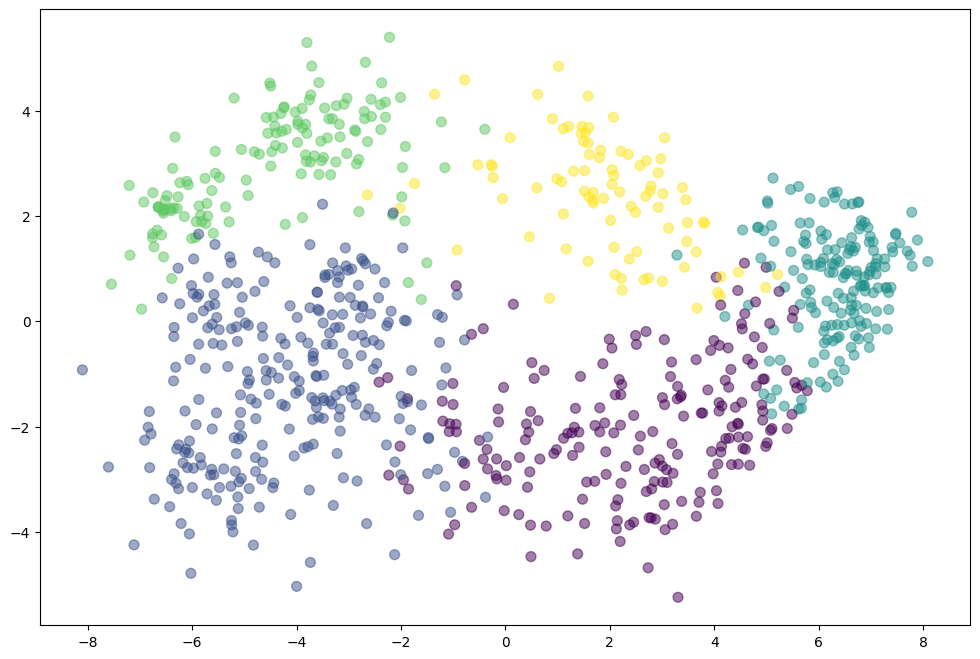

In [20]:
plot_agg_clustering(5, 'ward')

Using "Ward" as a linkage is the best match for our PCA chosen features. However, let us try and compare it with other possible methods.

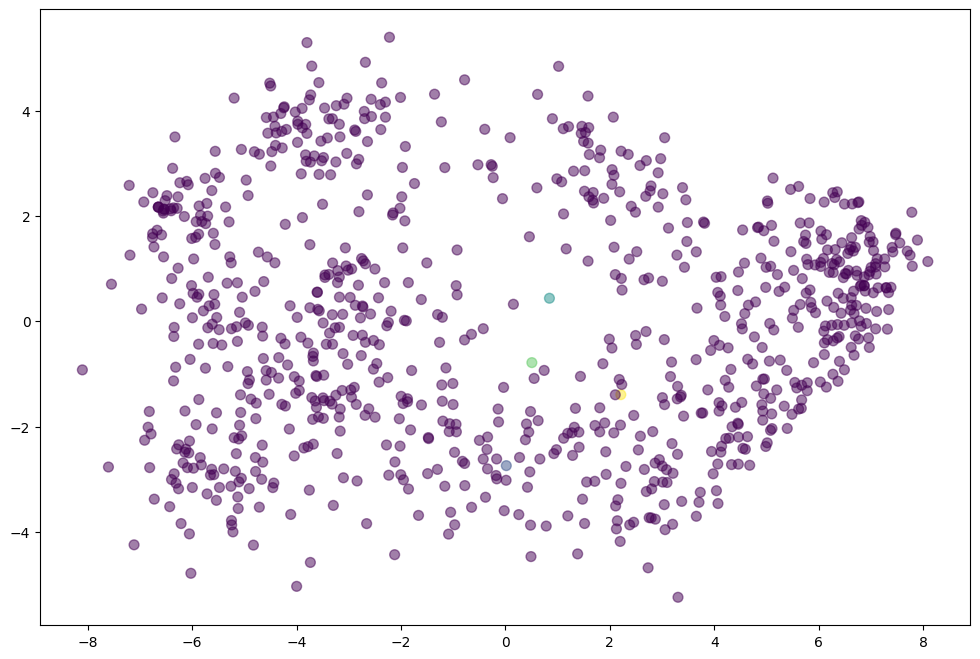

In [21]:
plot_agg_clustering(5, 'single')

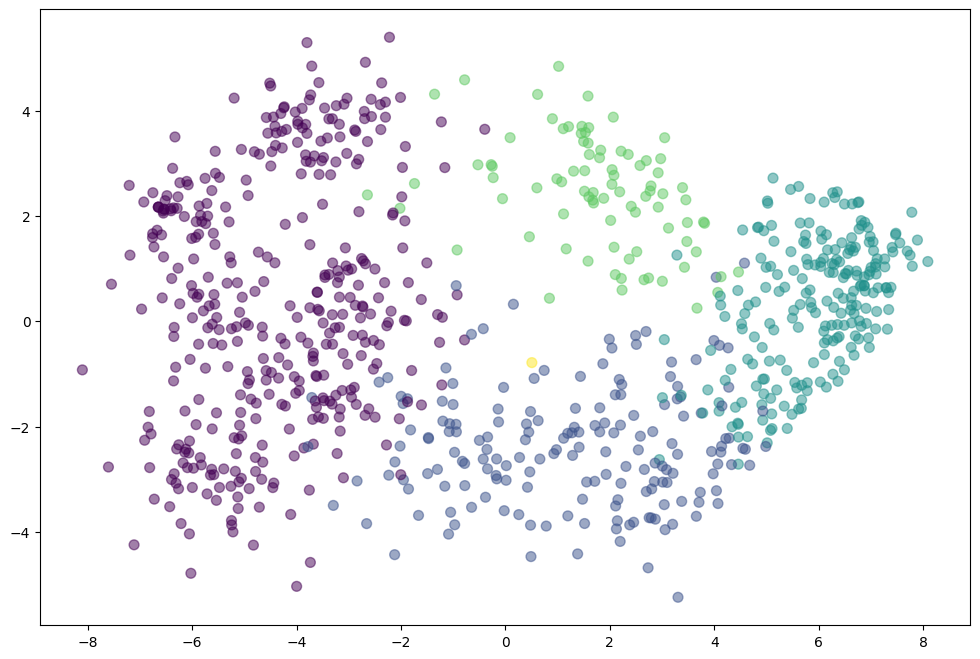

In [22]:
plot_agg_clustering(5, 'average')

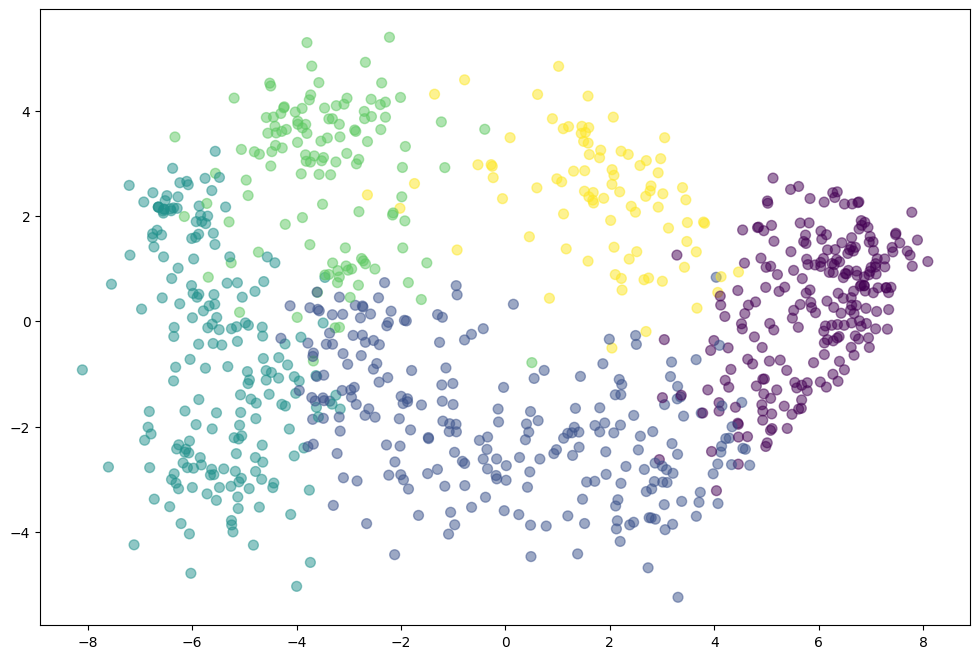

In [23]:
plot_agg_clustering(5, 'complete')

As we can see, the ward is matching best our expectations, with complete method performing almost evenly well. The reason being its use of maximum distance between any two points in the two clusters which creates evenly-spaced clusters.

As a sanity check, let us try to see the clustering for the real-life values.

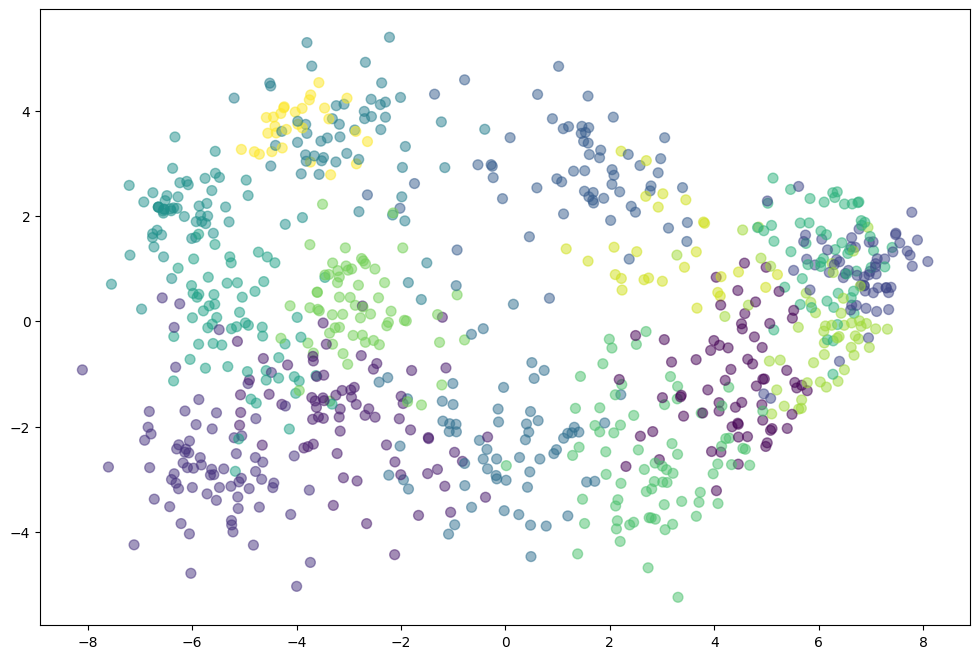

In [24]:
plot_agg_clustering(15, 'ward')

15 clusters seems a bit too much based on this outcome.

#### DBSCAN

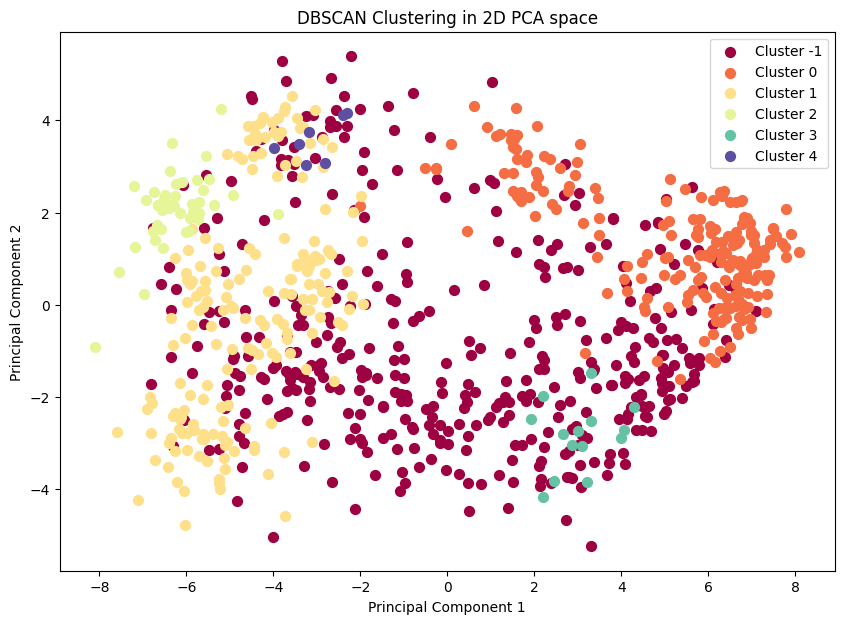

In [25]:
dbscan = DBSCAN(eps=6, min_samples=10)
clusters = dbscan.fit_predict(X)

plt.figure(figsize=(10, 7))

unique_clusters = np.unique(clusters)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_clusters)))

for cluster, color in zip(unique_clusters, colors):
    cluster_mask = (clusters == cluster)
    plt.scatter(pca_result[cluster_mask, 0], pca_result[cluster_mask, 1], s=50, c=[color], label=f"Cluster {cluster}")

plt.title("DBSCAN Clustering in 2D PCA space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

### An overview of the political landscape of the elected candidates

In [26]:
def compute_pairwise_difference(df):
    diff_df = pd.DataFrame(index=df.index, columns=df.index)
    for i in df.index:
        for j in df.index:
            diff_df.loc[i, j] = np.abs(df.loc[i].subtract(df.loc[j])).sum()
    return diff_df

numeric_columns = electeddata.drop(columns=['alder', 'navn', 'storkreds']).select_dtypes(include=[np.number]).columns
difference_df = compute_pairwise_difference(electeddata[numeric_columns])

flat_diffs = difference_df.unstack().sort_values(ascending=False)
flat_diffs = flat_diffs[flat_diffs.index.get_level_values(0) != flat_diffs.index.get_level_values(1)]

In [31]:
most_disagreeable_pairs = flat_diffs.head(10)
print("-----Pairs of Elected Candidates with the Highest Disagreements-----")
for (candidate_1, candidate_2), value in most_disagreeable_pairs.items():
    name_1 = electeddata.loc[candidate_1, 'navn']
    party_1 = electeddata.loc[candidate_1, 'parti']
    letter_1 = party_mapping.get(party_1, "?")
    
    name_2 = electeddata.loc[candidate_2, 'navn']
    party_2 = electeddata.loc[candidate_2, 'parti']
    letter_2 = party_mapping.get(party_2, "?")
    
    print(f"{name_1} ({party_1} - {letter_1}) vs {name_2} ({party_2} - {letter_2}): Total Difference Score = {value:.2f}")

-----Pairs of Elected Candidates with the Highest Disagreements-----
Sandra Elisabeth Skalvig (Liberal Alliance - I) vs Peder Hvelplund (Enhedslisten - Ø): Total Difference Score = 141.00
Peder Hvelplund (Enhedslisten - Ø) vs Sandra Elisabeth Skalvig (Liberal Alliance - I): Total Difference Score = 141.00
Karina Lorentzen Dehnhardt (Socialistisk Folkeparti - F) vs Ole Birk Olesen (Liberal Alliance - I): Total Difference Score = 140.00
Steffen Frølund (Liberal Alliance - I) vs Peder Hvelplund (Enhedslisten - Ø): Total Difference Score = 140.00
Ole Birk Olesen (Liberal Alliance - I) vs Karina Lorentzen Dehnhardt (Socialistisk Folkeparti - F): Total Difference Score = 140.00
Henrik Dahl (Liberal Alliance - I) vs Peder Hvelplund (Enhedslisten - Ø): Total Difference Score = 140.00
Peder Hvelplund (Enhedslisten - Ø) vs Steffen Frølund (Liberal Alliance - I): Total Difference Score = 140.00
Peder Hvelplund (Enhedslisten - Ø) vs Henrik Dahl (Liberal Alliance - I): Total Difference Score = 140.

In [ ]:
most_agreeable_pairs = flat_diffs.tail(10)
print("-----Top 10 Pairs of Elected Candidates with the Most Agreements-----")
for (candidate_1, candidate_2), value in most_agreeable_pairs.items():
    name_1 = electeddata.loc[candidate_1, 'navn']
    party_1 = electeddata.loc[candidate_1, 'parti']
    letter_1 = party_mapping.get(party_1, "?")
    
    name_2 = electeddata.loc[candidate_2, 'navn']
    party_2 = electeddata.loc[candidate_2, 'parti']
    letter_2 = party_mapping.get(party_2, "?")
    
    print(f"{name_1} ({party_1} - {letter_1}) and {name_2} ({party_2} - {letter_2}): Total Agreement Score = {value:.2f}")

-----Top 10 Pairs of Elected Candidates with the Most Agreement-----
Pernille Vermund (Nye Borgerlige - D) and Kim Edberg (Nye Borgerlige - D): Total Agreement Score = 3.00
Jakob Ellemann-Jensen (Venstre - V) and Karen Ellemann (Venstre - V): Total Agreement Score = 3.00
Kim Edberg (Nye Borgerlige - D) and Peter Seier Christensen (Nye Borgerlige - D): Total Agreement Score = 2.00
Trine Bramsen (Socialdemokratiet - A) and Rasmus Stoklund (Socialdemokratiet - A): Total Agreement Score = 2.00
Peter Seier Christensen (Nye Borgerlige - D) and Kim Edberg (Nye Borgerlige - D): Total Agreement Score = 2.00
Rasmus Stoklund (Socialdemokratiet - A) and Trine Bramsen (Socialdemokratiet - A): Total Agreement Score = 2.00
Pernille Vermund (Nye Borgerlige - D) and Peter Seier Christensen (Nye Borgerlige - D): Total Agreement Score = 1.00
Lea Wermelin (Socialdemokratiet - A) and Rasmus Stoklund (Socialdemokratiet - A): Total Agreement Score = 1.00
Rasmus Stoklund (Socialdemokratiet - A) and Lea Wermel

Shockingly, all the most agreeing elected members are from within the same parties whereas the most disagreeing are from different parties. An expert with a domain knowledge could define, whether the most disagreeing parties are as well the opposing ones or there are some unexpected disagreements.